In [1]:
import matplotlib.pyplot as plt
from collections import Counter

from Bio import SeqIO
from Bio.SeqUtils import MeltingTemp as mt 
from Bio.SeqUtils import molecular_weight as mw 
from Bio.SeqUtils import gc_fraction 
from Bio.SeqUtils import nt_search
from Levenshtein import distance
from Bio.pairwise2 import format_alignment, align

In [ ]:
seqA = SeqIO.read('a.fasta', 'fasta').seq
seqB = SeqIO.read('b.fasta', 'fasta').seq
print(len(seqA) + len(seqB))


2933
XM_006779407.2


In [3]:
nt_search(str(seqA), 'TAC')[1]

507

In [5]:
first = seqA[:10:]
last = seqB[-15::]
combine = first + last
seqC = combine[::-1]
seqC

Seq('CAGCTGAAAGCGGACGGTTGTGGTA')

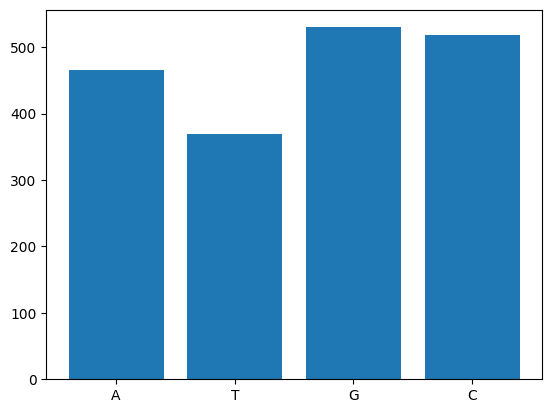

In [6]:
countA = Counter(seqA)
countB = Counter(seqB)
plt.bar(countA.keys(), countA.values())
plt.show()

In [8]:
gc_a = gc_fraction(seqA) * 100
print(f"gc: {gc_a:.2f}%")
print(f"at: {100 - gc_a:.2f}%")

gc: 55.71%
at: 44.29%


In [ ]:
mt.Tm_Wallace(seqA)

5864.0

In [10]:
mw(seqA)

582470.8097999999

In [11]:
mRNA_a = seqA.transcribe()
mRNA_a

Seq('AUGGUGUUGGAUCUGGACUUGUUUCGGACGGAUAAAGGAGGAGACCCGGACCGC...UCA')

In [12]:
aminoAcid_a = mRNA_a.translate()
aminoAcid_a

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\Bio\Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


Seq('MVLDLDLFRTDKGGDPDRIRETQKNRFKDPGLVDRLVKADGEWRKCRFQTDNLN...VAS')

In [14]:
local_alignment_a = align.localxx(seqA, 'CGCTACTAGCATGCGCAT')
for a in local_alignment_a:
    print(format_alignment(*a))

1815 CAGCTCTCCCTGGAACCACACTCACTTGTGCTTTTCCTCCTAAATAAAGCTGTTCCATGTAGCAAGT
     | |      ||        ||| |     |         |       |  ||   |     || | |
   1 C-G------CT--------ACT-A-----G---------C-------A--TG---C-----GC-A-T
  Score=18

1813 CACAGCTCTCCCTGGAACCACACTCACTTGTGCTTTTCCTCCTAAATAAAGCTGTTCCATGTAGCAAGT
     |   |      ||        ||| |     |         |       |  ||   |     || | |
   1 C---G------CT--------ACT-A-----G---------C-------A--TG---C-----GC-A-T
  Score=18

1811 CTCACAGCTCTCCCTGGAACCACACTCACTTGTGCTTTTCCTCCTAAATAAAGCTGTTCCATGTAGCAAGT
     |     |      ||        ||| |     |         |       |  ||   |     || | |
   1 C-----G------CT--------ACT-A-----G---------C-------A--TG---C-----GC-A-T
  Score=18

1807 CTGGCTCACAGCTCTCCCTGGAACCACACTCACTTGTGCTTTTCCTCCTAAATAAAGCTGTTCCATGTAGCAAGT
     |         |      ||        ||| |     |         |       |  ||   |     || | |
   1 C---------G------CT--------ACT-A-----G---------C-------A--TG---C-----GC-A-T
  Score=18

1806 CCTGGCTCACAGCTCTCCCTGGAACCACA

In [15]:
global_alignment_a = align.globalxx(seqA, 'CAGTGCGCTAGCAGCTACGTGTG”')
for a in global_alignment_a:
    print(format_alignment(*a))

ATGGTGTTGGATCTGGACTTGTTTCGGACGGATAAAGGAGGAGACCCGGACCGCATCCGAGAGACGCAAAAGAACCGCTTCAAGGACCCGGGACTCGTGGATCGGCTGGTGAAGGCGGACGGCGAGTGGCGAAAATGCAGATTTCAGACCGACAACTTGAACAAGCTGAAGAACCTATGCAGCAAGACAATTGGAGAGAAAATGAAGAAAAAAGAGCCAGTGGGAAATGATGAGTCCATTCCGGAGAACTTGTTAAATCTCGATGACCTCACTTCAGACACTTTAGCTAACCTGAAAGTGTCACAGATCAAAAAACTCCGACTCCTCATCGACGAAGCCATCCTGAAGTGTGACGCCCAGCGGATAAAGCTGCAGGAATAGCGGTTTGAGAACCTCCGCGAGCGATTCGATGGCTAGGTCCTGCATCCCTCGGTGCCCATCAGTAACGATGAGGATGCGGACAACAAAGTCGAGAGGATCTGGGGTGACTGCACCGTCAAGAAGAAGTACTCGCACGTGGACCTGGTGGTGATGGTCGATGGCTTTGAAGGCGAAAAAGGGGTCGTGGTGGCTGGCAGTCGAGGGTACTTCCTGAAGGGGCCCCTGGTGTTCCTGGAACAGGCGCTCATCCAGTACGCCCTTCGCACCTTGGGAAGTCGGGGCTACATTCCCATTTACACCCCGTTTTTCATGAGGAAGGAGGTCATGCAGGAGGTGGCACAGCTCAGCCAGTTTGATGAAGAGCTTTACAAGGTGATTGGCAAAGGCAGTGAAAAGTCTGACGACAACTCCTACGATGAGAAATACCTGATTGCCACCTCCGAGCAGCCCATCGCTGCTCTCCACCGAGATGAGTGGCTACGGCCAGAGGATTTGCCCATCAAGTATGCTGGCCTGTCCACCTGCTTTCGCCAGGAGGTGGGCTCCCACGGCCGGGACACCCGCGGCATCTTCCGAGTCCATCAGTTTGAGAAGATCGAGCAGTTTGTCTACGCGTCAC